In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

In [14]:
conn = pyodbc.connect(
    'Driver={Sql Server};'
    'Server=DESKTOP-3TC82P7;'
    'Database=ProjectWeek;'
    'Trusted_Connection=yes;'
)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20444\1751018801.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


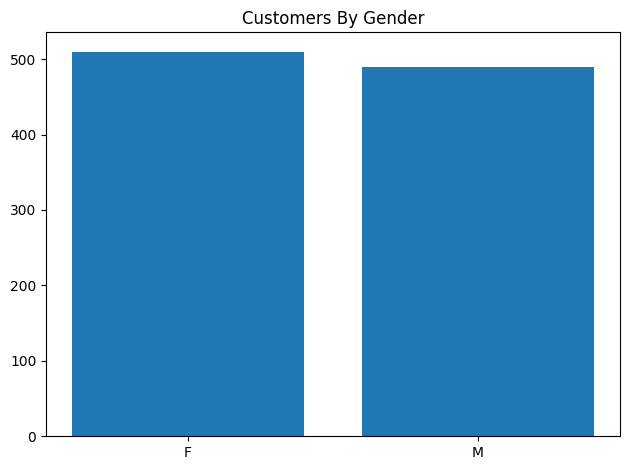

In [17]:
# By Gender
query = """
SELECT 
	gender, 
	COUNT(DISTINCT customer_id) AS total_customer
FROM dbo.retail_sales
GROUP BY gender;
"""
df = pd.read_sql(query, conn)
plt.bar(df['gender'], df['total_customer'])
plt.title('Customers By Gender')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20444\2213408283.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


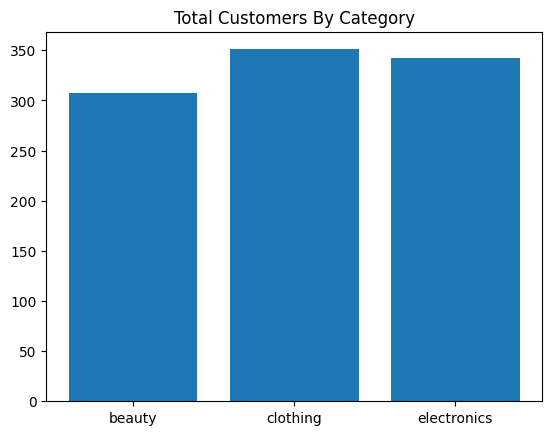

In [18]:
# Product Category
query = """
SELECT 
    product_category,
	COUNT(DISTINCT customer_id) AS total_customer
FROM dbo.retail_sales
GROUP BY product_category;
"""
df = pd.read_sql(query, conn)
plt.bar(df['product_category'], df['total_customer'])
plt.title('Total Customers By Category')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20444\1212212087.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


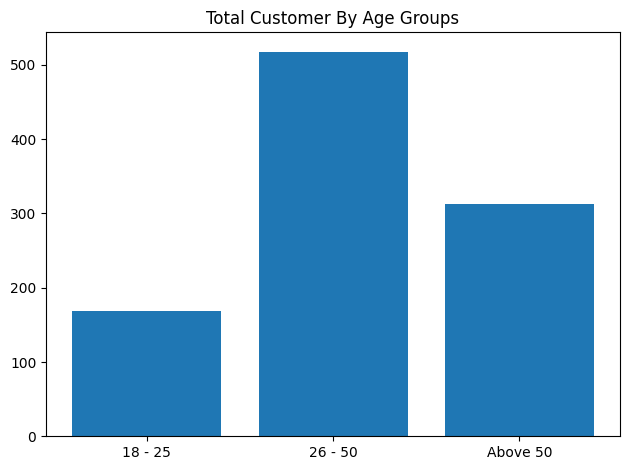

In [20]:
# Age Groups
query = """
WITH CTE_Segment AS (
SELECT
	*,
	CASE WHEN age < 18 THEN 'Under 18'
		 WHEN age BETWEEN 18 AND 25 THEN '18 - 25'
		 WHEN age BETWEEN 26 AND 50 THEN '26 - 50'
		 ELSE 'Above 50'
	END AS age_group 
FROM dbo.retail_sales
)
SELECT 
	age_group,
	COUNT(DISTINCT customer_id) AS total_customer
FROM CTE_Segment 
GROUP BY age_group;
"""
df = pd.read_sql(query, conn)
plt.bar(df['age_group'], df['total_customer'])
plt.title('Total Customer By Age Groups')
plt.tight_layout()
plt.show()